In [4]:
import pandas as pd

df = pd.read_csv("../data/customer_support_tickets_clean.csv")

df.head()

,subject,body,answer,type,queue,priority,ticket_text,clean_text
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,"Account Disruption Dear Customer Support Team,...",account disruption dear customer support team ...
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,Query About Smart Home System Integration Feat...,query about smart home system integration feat...
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,Inquiry Regarding Invoice Details Dear Custome...,inquiry regarding invoice details dear custome...
3,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,Question About Marketing Agency Software Compa...,question about marketing agency software compa...
4,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Thank you for your inquiry. Please specify whi...,Request,Technical Support,high,"Feature Query Dear Customer Support,\n\nI hope...",feature query dear customer support i hope thi...


In [5]:
df.shape

(16335, 8)

In [6]:
X = df["clean_text"]

y_queue = df["queue"]

y_priority = df["priority"]

In [7]:
print(X.head())

print()

print(y_queue.head())

print()

print(y_priority.head())

0    account disruption dear customer support team ...
1    query about smart home system integration feat...
2    inquiry regarding invoice details dear custome...
3    question about marketing agency software compa...
4    feature query dear customer support i hope thi...
Name: clean_text, dtype: object

0        Technical Support
1    Returns and Exchanges
2     Billing and Payments
3      Sales and Pre-Sales
4        Technical Support
Name: queue, dtype: object

0      high
1    medium
2       low
3    medium
4      high
Name: priority, dtype: object


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_queue_train, y_queue_test = train_test_split(
    X,
    y_queue,
    test_size=0.2,
    random_state=42,
    stratify=y_queue
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print()

print("Training labels:", y_queue_train.shape[0])
print("Testing labels:", y_queue_test.shape[0])

Training samples: 13068
Testing samples: 3267

Training labels: 13068
Testing labels: 3267


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

In [10]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(13068, 5367)
(3267, 5367)


In [11]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(
    X_train_tfidf,
    y_queue_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [12]:
y_pred = lr_model.predict(X_test_tfidf)

print(y_pred[:10])

['Product Support' 'Technical Support' 'Technical Support'
 'Technical Support' 'Product Support' 'Product Support'
 'Technical Support' 'Product Support' 'IT Support' 'Technical Support']


In [13]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(
    y_queue_test,
    y_pred
)

print("Accuracy:", accuracy)

print(classification_report(
    y_queue_test,
    y_pred
))

Accuracy: 0.47689011325374964
                                 precision    recall  f1-score   support

           Billing and Payments       0.87      0.68      0.76       319
               Customer Service       0.38      0.37      0.37       482
                General Inquiry       1.00      0.04      0.08        47
                Human Resources       1.00      0.11      0.21        70
                     IT Support       0.47      0.23      0.31       388
                Product Support       0.39      0.43      0.41       614
          Returns and Exchanges       0.74      0.10      0.18       164
            Sales and Pre-Sales       0.68      0.13      0.21       103
Service Outages and Maintenance       0.81      0.50      0.62       133
              Technical Support       0.45      0.74      0.56       947

                       accuracy                           0.48      3267
                      macro avg       0.68      0.33      0.37      3267
                   

In [14]:
df["queue"].value_counts()

queue
Technical Support                  4736
Product Support                    3071
Customer Service                   2410
IT Support                         1942
Billing and Payments               1595
Returns and Exchanges               820
Service Outages and Maintenance     664
Sales and Pre-Sales                 513
Human Resources                     348
General Inquiry                     236
Name: count, dtype: int64

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train_tfidf, y_queue_train)
y_pred = lr_model.predict(X_test_tfidf)

(13068, 47715)
(3267, 47715)


In [16]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_queue_test, y_pred)
print("Accuracy:", accuracy)

print(classification_report(y_queue_test, y_pred))

Accuracy: 0.5411692684419958
                                 precision    recall  f1-score   support

           Billing and Payments       0.89      0.69      0.78       319
               Customer Service       0.50      0.46      0.48       482
                General Inquiry       0.00      0.00      0.00        47
                Human Resources       1.00      0.10      0.18        70
                     IT Support       0.64      0.27      0.38       388
                Product Support       0.48      0.51      0.49       614
          Returns and Exchanges       1.00      0.13      0.24       164
            Sales and Pre-Sales       0.86      0.12      0.21       103
Service Outages and Maintenance       0.86      0.49      0.62       133
              Technical Support       0.49      0.85      0.62       947

                       accuracy                           0.54      3267
                      macro avg       0.67      0.36      0.40      3267
                   w

c:\Users\Dikshya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dikshya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dikshya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

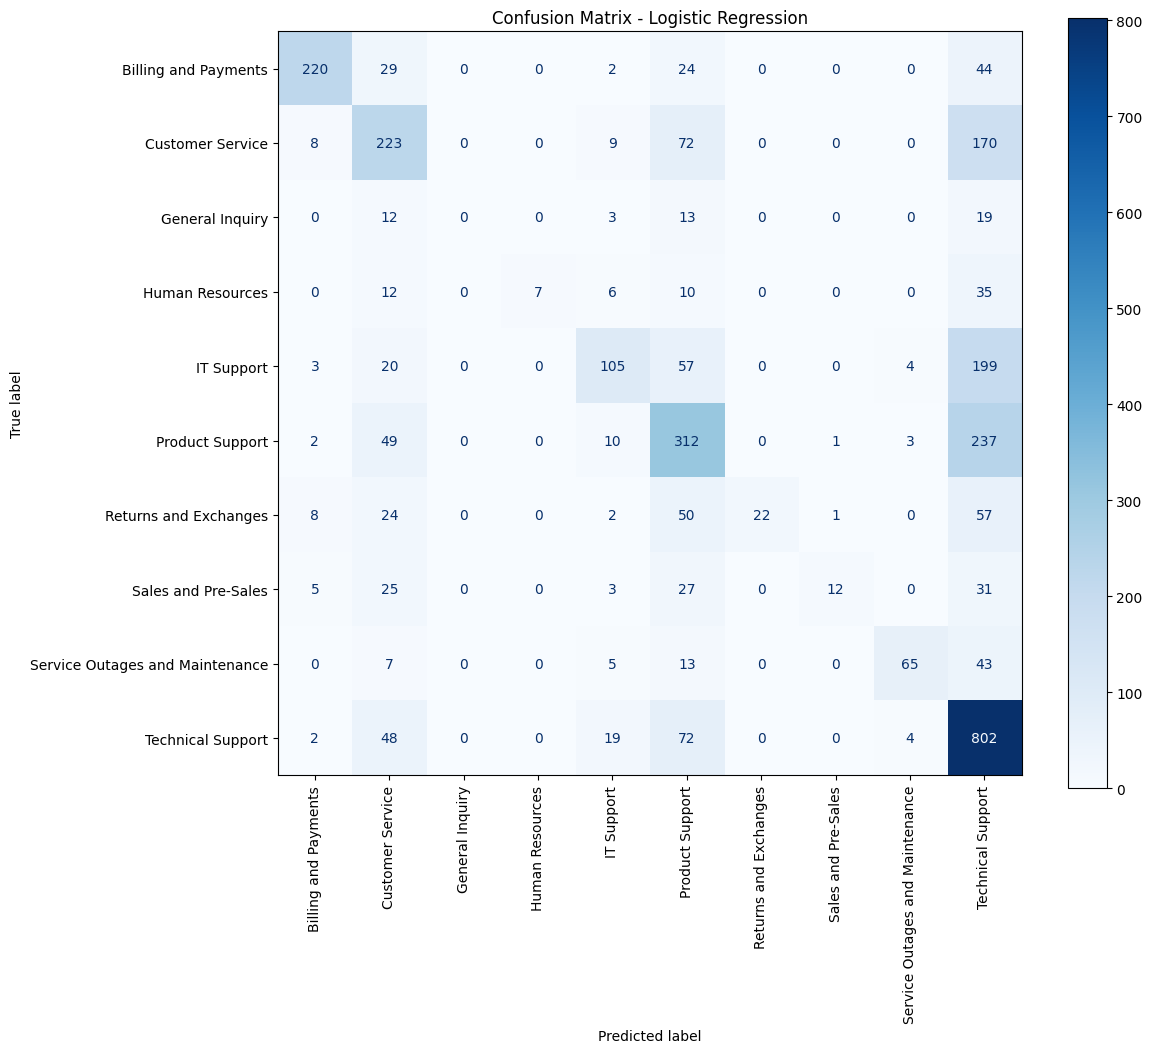

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,10))

ConfusionMatrixDisplay.from_estimator(
    lr_model,
    X_test_tfidf,
    y_queue_test,
    xticks_rotation=90,
    cmap="Blues",
    ax=ax
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()